# Mental Health in Tech: Inferential Statistical Analysis

**Authors:** Arthur Vinícius de Albuquerque Oliveira, Anny Karoliny Germano Filgueiras, João Victor Rodrigues Alves  
**Academic Context:** Probability & Statistics — Universidade Federal de Alagoas (UFAL)

---

### Research Objectives
This project evaluates the behavioral and demographic factors associated with mental health treatment seeking in the tech industry using survey data ($N = 1,259$).

We formulate and test three hypotheses:
1. **Hypothesis 1 (Age vs. Treatment):** Does mean age differ significantly between professionals who seek treatment and those who do not?
2. **Hypothesis 2 (Family History vs. Treatment):** Is having a family history of mental illness associated with higher treatment-seeking rates?
3. **Hypothesis 3 (Age vs. Workplace Interference):** Is there a correlation between worker age and how frequently mental health interferes with work?

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

possible_paths = [
    Path("data/survey.csv"),
    Path("../data/survey.csv"),
    Path("survey.csv"),
]
data_path = next((p for p in possible_paths if p.exists()), None)

if data_path is None:
  raise FileNotFoundError("Could not find survey.csv")

df = pd.read_csv(data_path)

# filter invalid ages and missing data
df = df[(df["Age"] > 10) & (df["Age"] < 100)].copy()
features = ["Age", "Gender", "treatment", "family_history", "work_interfere"]
df = df[features].dropna().copy()

# 3. mappins for analysis 
df["treatment_num"] = df["treatment"].map({"Yes": 1, "No": 0})
df["family_history_num"] = df["family_history"].map({"Yes": 1, "No": 0})
df["work_interfere_num"] = df["work_interfere"].map(
    {"Never": 0, "Rarely": 1, "Sometimes": 2, "Often": 3}
)

print(f"Dataset ready. Sample size: N = {len(df)}")
print(f"Overall mean age: {df['Age'].mean():.2f} years")
df.head()

Dataset ready. Sample size: N = 990
Overall mean age: 32.30 years


,Age,Gender,treatment,family_history,work_interfere,treatment_num,family_history_num,work_interfere_num
0,37,Female,Yes,No,Often,1,0,3
1,44,M,No,No,Rarely,0,0,1
2,32,Male,No,No,Rarely,0,0,1
3,31,Male,Yes,Yes,Often,1,1,3
4,31,Male,No,No,Never,0,0,0


## Hypothesis 1: Age vs. Treatment Seeking
* **Null Hypothesis ($H_0$):** $\mu_{\text{treated}} = \mu_{\text{untreated}}$ (mean age is equal across both groups)
* **Alternative Hypothesis ($H_a$):** $\mu_{\text{treated}} \neq \mu_{\text{untreated}}$
* **Test:** Welch's two-sample $t$-test ($\alpha = 0.05$)

Mean age (Treated):   32.61
Mean age (Untreated): 31.76
t-statistic = 1.7788 | p-value = 0.0757
Decision: Fail to reject H0


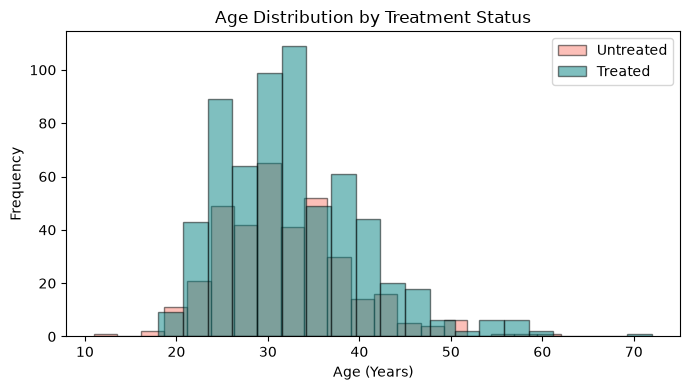

In [2]:
treated = df[df["treatment_num"] == 1]["Age"]
untreated = df[df["treatment_num"] == 0]["Age"]

t_stat, p_val1 = stats.ttest_ind(treated, untreated, equal_var=False)

print(f"Mean age (Treated):   {treated.mean():.2f}")
print(f"Mean age (Untreated): {untreated.mean():.2f}")
print(f"t-statistic = {t_stat:.4f} | p-value = {p_val1:.4f}")
print("Decision:", "Reject H0" if p_val1 < 0.05 else "Fail to reject H0")

plt.figure(figsize=(7, 4))
plt.hist(
    untreated, bins=20, alpha=0.5, label="Untreated", color="salmon", ec="black"
)
plt.hist(treated, bins=20, alpha=0.5, label="Treated", color="teal", ec="black")
plt.title("Age Distribution by Treatment Status")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## Hypothesis 2: Family History vs. Treatment Seeking
* **Null Hypothesis ($H_0$):** $p_{\text{history}} = p_{\text{no\_history}}$ (treatment rates are independent of family history)
* **Alternative Hypothesis ($H_a$):** $p_{\text{history}} > p_{\text{no\_history}}$
* **Method:** 95% Confidence Intervals for Proportions

With Family History:    80.9% (95% CI: [77.3%, 84.6%])
Without Family History: 49.1% (95% CI: [44.9%, 53.3%])
Decision: Reject H0


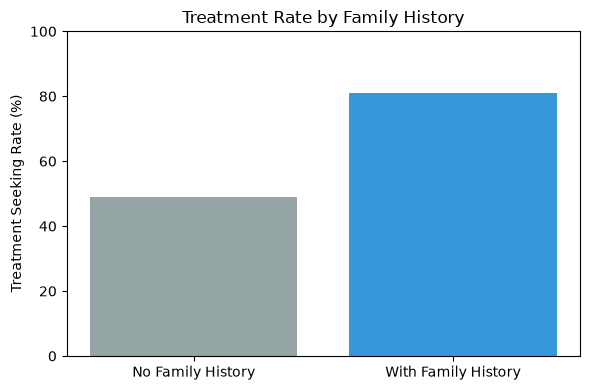

In [3]:
def get_ci(successes, n):
  p = successes / n
  margin = 1.96 * np.sqrt(p * (1 - p) / n)
  return p, p - margin, p + margin


group_fam = df[df["family_history_num"] == 1]
group_nofam = df[df["family_history_num"] == 0]

p_fam, low_fam, high_fam = get_ci(
    group_fam["treatment_num"].sum(), len(group_fam)
)
p_nofam, low_nofam, high_nofam = get_ci(
    group_nofam["treatment_num"].sum(), len(group_nofam)
)

print(
    f"With Family History:    {p_fam:.1%} (95% CI: [{low_fam:.1%},"
    f" {high_fam:.1%}])"
)
print(
    f"Without Family History: {p_nofam:.1%} (95% CI: [{low_nofam:.1%},"
    f" {high_nofam:.1%}])"
)

overlaps = not (high_fam < low_nofam or high_nofam < low_fam)
print("Decision:", "Fail to reject H0" if overlaps else "Reject H0")

plt.figure(figsize=(6, 4))
plt.bar(
    ["No Family History", "With Family History"],
    [p_nofam * 100, p_fam * 100],
    color=["#95a5a6", "#3498db"],
)
plt.ylabel("Treatment Seeking Rate (%)")
plt.title("Treatment Rate by Family History")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## Hypothesis 3: Age vs. Workplace Interference
* **Null Hypothesis ($H_0$):** $\rho = 0$ (no correlation between age and work interference)
* **Alternative Hypothesis ($H_a$):** $\rho \neq 0$
* **Test:** Pearson correlation coefficient ($\alpha = 0.05$)

Pearson r = -0.0396 | p-value = 0.2133
Decision: Fail to reject H0 (No significant correlation)


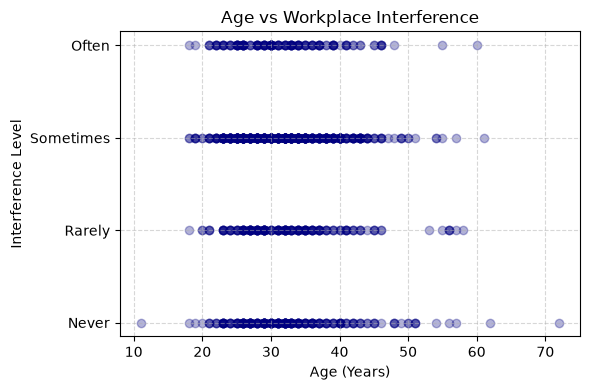

In [4]:
corr, p_val3 = stats.pearsonr(df["Age"], df["work_interfere_num"])

print(f"Pearson r = {corr:.4f} | p-value = {p_val3:.4f}")
# p >= 0.05 means there is no statistically significant correlation
print(
    "Decision:",
    "Reject H0"
    if p_val3 < 0.05
    else "Fail to reject H0 (No significant correlation)",
)

plt.figure(figsize=(6, 4))
plt.scatter(df["Age"], df["work_interfere_num"], alpha=0.3, color="navy")
plt.yticks([0, 1, 2, 3], ["Never", "Rarely", "Sometimes", "Often"])
plt.xlabel("Age (Years)")
plt.ylabel("Interference Level")
plt.title("Age vs Workplace Interference")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Summary of Results

| Hypothesis | Test | Key Metric | Result | Decision |
| :--- | :--- | :--- | :--- | :--- |
| **$H_1$: Age vs Treatment** | Welch's $t$-test | $t = 1.7788, p = 0.0757$ | Difference is not significant | Fail to reject $H_0$ |
| **$H_2$: Family History** | Proportion CIs | $80.9\%$ vs. $49.1\%$ | Non-overlapping 95% CIs | **Reject $H_0$** |
| **$H_3$: Age vs Interference** | Pearson correlation | $r = -0.0396, p = 0.2133$ | Very weak, non-significant | Fail to reject $H_0$ |

### Key Takeaways
1. **Family history is the primary behavioral driver:** Having family members with mental health issues increases the likelihood of seeking treatment by over 30 percentage points.
2. **Age is invariant:** Older employees are not significantly more or less likely to seek care, nor do they report substantially different levels of mental health disruption during daily work.